In [ ]:
import torch
import sys
import os
from pathlib import Path
cwd = Path.cwd()

def find_cajal_root(start=cwd):
    p = start
    while True:
        if (p / 'src').is_dir() and (p / 'scTopoGAN').is_dir():
            return str(p)
        if p.parent == p:
            return str(start)
        p = p.parent

h = find_cajal_root()
cajal_root = h if os.path.basename(h) == 'cajal' else os.path.join(h, 'cajal')
if cajal_root not in sys.path:
    sys.path.insert(0, cajal_root)

    
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
import torch
import pytorch_lightning as pl
from torch.utils.data import DataLoader, Dataset
from pbmc_args import get_namespace
from src.continuous.mec_last import MEC

import pytorch_lightning as pl
from src.models.new_mlp import ConditionalDenoiserMLP




def robust_isotropic_standardize(X, clip_threshold=None):
    med = np.median(X, axis=0)           # shape = (n_features,)
    Xc = X - med[np.newaxis, :]          # zero-median per feature
    mad = np.median(np.abs(Xc))          # single scalar
    robust_std = mad * 1.4826            # approx σ if data were normal
    Xs = Xc / robust_std

    # 4) (Optional) Clip extreme values, *but this will only affect those points*
    if clip_threshold is not None:
        Xs = np.clip(Xs, -clip_threshold, clip_threshold)

    return Xs, med, robust_std


class IndependentDataset(Dataset):
    def __init__(self, data):
        """Simple dataset wrapper that shuffles each epoch."""
        self.data = data
        self.indices = torch.randperm(len(self.data))  # Initial shuffle

    def shuffle_indices(self):
        """Shuffle indices for a new epoch."""
        self.indices = torch.randperm(len(self.data))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[self.indices[idx]]


class MultiModalDataModule(pl.LightningDataModule):
    def __init__(self, x1, x2, batch_size=64, num_workers=4):
        super().__init__()
        self.batch_size = batch_size
        self.num_workers = num_workers

        self.x1_dataset = IndependentDataset(x1)
        self.x2_dataset = IndependentDataset(x2)

    def setup(self, stage=None):
        """Setup is called at the start of training/validation/testing."""
        pass  # Nothing to do since datasets are already initialized

    def train_dataloader(self):
        """Creates DataLoaders that ensure independent shuffling per epoch."""
        # self.x1_dataset.shuffle_indices()  # Shuffle x1
        # self.x2_dataset.shuffle_indices()  # Shuffle x2

        g1 = torch.Generator()
        g1.manual_seed(torch.initial_seed() % 2**32)  # Seed for x1

        g2 = torch.Generator()
        g2.manual_seed((torch.initial_seed() + 1) % 2**32)  # Different seed for x2

        print("shuffeling data")

        x1_loader = DataLoader(self.x1_dataset, batch_size=self.batch_size, 
                               shuffle=True, num_workers=self.num_workers, drop_last=True,generator=g1)
        x2_loader = DataLoader(self.x2_dataset, batch_size=self.batch_size, 
                               shuffle=True, num_workers=self.num_workers, drop_last=True,generator=g2)

        return  x1_loader,  x2_loader

    def val_dataloader(self):
        """Validation DataLoaders (can be handled similarly)."""
        return self.train_dataloader()  # Same logic for now

class mod():
    def __init__(self,name="x",size= 17):
        self.name = name
        self.size = size




parser = get_namespace()
args = parser.parse_args([])
pl.seed_everything(args.seed)
from data_loader import load_pbmc_data
  
source_tech, target_tech, meta_source, meta_target = load_pbmc_data()

source_indices = list(source_tech.index)
target_indices = list(target_tech.index)

X = source_tech.to_numpy()
X = X.astype(float)
y = target_tech.to_numpy()
y = y.astype(float)


X, med_X, std_X = robust_isotropic_standardize(X,clip_threshold=15)
y, med_y, std_y = robust_isotropic_standardize(y,clip_threshold=25)


intervals = [[np.min(X),np.max(X)],[np.min(y),np.max(y)]]
modalities = [mod("x",X.shape[1]), mod("y",y.shape[1])]

data = MultiModalDataModule(x1=X[np.random.permutation(X.shape[0])],x2=y[np.random.permutation(y.shape[0])],batch_size=args.bs )
   
    

model1 = ConditionalDenoiserMLP(input_dim=X.shape[1],cond_dim=y.shape[1],embedding_dim=128,hidden_dim=128*3,cond_method=args.cond_method)
model2 = ConditionalDenoiserMLP(input_dim=y.shape[1],cond_dim=X.shape[1],embedding_dim=128,hidden_dim=128*3,cond_method=args.cond_method)
 
stat = [{"mean": np.mean(X),"std":np.std(X)},{"mean": np.mean(y),"std":np.std(y)}]



model = MEC(modalities,models=[model1,model2],
                exp ="PBMC",intervals = intervals, 
                preporcess=None,
                args=args,stat = stat,
                test_set = {"x1" : {"Celltype":meta_target["Celltype"],"Subcelltype":meta_target["Subcelltype"]},
                "x2" : {"Celltype":meta_target["Celltype"],"Subcelltype":meta_target["Subcelltype"]} },
                data=[torch.tensor(X),torch.tensor(y)]) 

model.set_up__priors_diffusion()
  
check = torch.hub.load_state_dict_from_url(
    "https://huggingface.co/buckets/mustabou/mybucket/resolve/pbmc.ckpt?download=true",
    map_location="cpu",   # or your device
    check_hash=False,
)
model.load_state_dict(check["state_dict"])
model = model.to("cuda")

    

Seed set to 88


({'CTM': [71.82097579715713, 70.8029197080292],
  'SCTM': [46.78255858624664, 49.64464079907799],
  'CTM_proj': [70.77410679984634, 70.4091432961967],
  'SCTM_proj': [45.57241644256627, 49.039569727237804]},
 <Figure size 1455.6x480 with 2 Axes>)

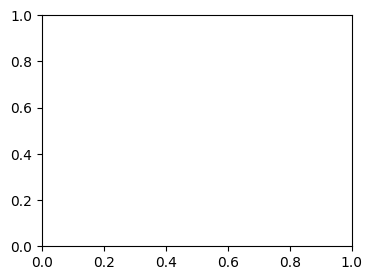

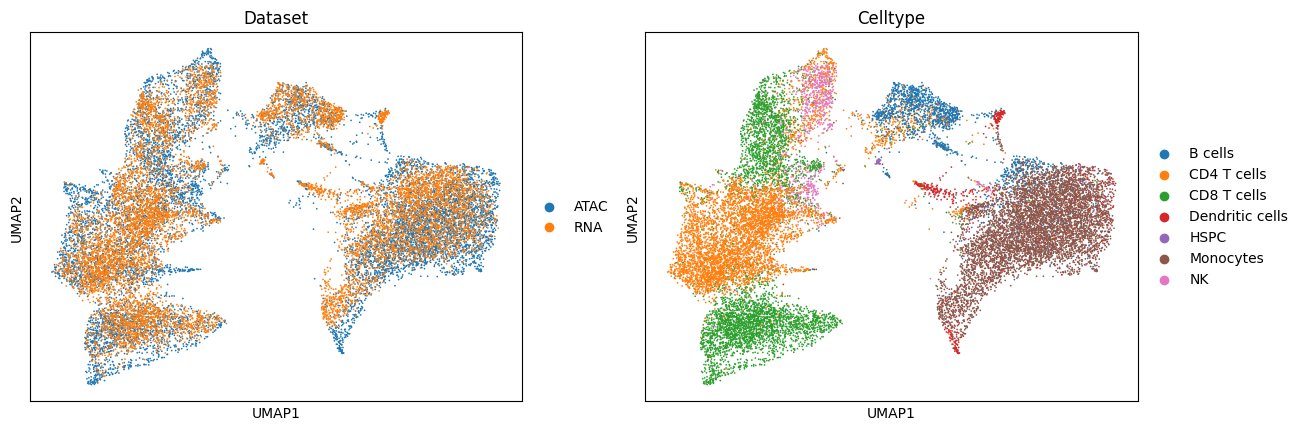

In [13]:

out =model.eval_coupling_2(guidance=3,nb_step=10,clip_gen=False,eta=0.1)
out

In [ ]:
# checkpoint path placeholder - set `args.path` or env var 'CKPT_PATH' if you want to load a checkpoint
